# Mesures of Variability(Dispersion)
    Measures of Variability are statistical measures that describe how spread out the data values are from the center of the dataset.

    While Measures of Central Tendency tell us the typical value, 
    
    Measures of Variability tell us how much the values differ from each other.

### Why is it Important?

    Suppose two stores have the same average customer purchase amount of ₹2,000.

    Store A: Most customers spend close to ₹2,000.
    Store B: Some customers spend very little, while others spend much more.

    Although the average is the same, the spending pattern is very different. Measures of Variability help us understand this difference.

### Business Applications
    Analyze customer spending patterns
    Compare employee salary variation
    Monitor product quality consistency
    Measure stock price volatility
    Assess financial and business risk

### Business Problem

    Example

    An e-commerce company wants to know whether customer purchase amounts are consistent or highly spread out.

    Two stores have the same average purchase amount, but one store has much more variation in customer spending.

    Question:
        Which store has more consistent customer spending?

In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statistics as st

In [8]:
pur = pd.DataFrame({
    "Purchase_Amount":[1200,1500,1800,1500,2200,
                       2500,1800,3000,1500,2700,
                       3500,1800,1500,4000,2500]
})

pur.head()

,Purchase_Amount
0,1200
1,1500
2,1800
3,1500
4,2200


In [11]:
pur.shape

(15, 1)

In [9]:
pur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Purchase_Amount  15 non-null     int64
dtypes: int64(1)
memory usage: 252.0 bytes


In [10]:
pur.describe()

,Purchase_Amount
count,15.000000
mean,2200.000000
std,821.149021
min,1200.000000
25%,1500.000000
50%,1800.000000
75%,2600.000000
max,4000.000000


In [14]:
# Mean
st.mean(pur['Purchase_Amount'])

2200

In [15]:
# Median
st.median(pur['Purchase_Amount'])

1800

In [16]:
# Mode
st.mode(pur['Purchase_Amount'])

1500

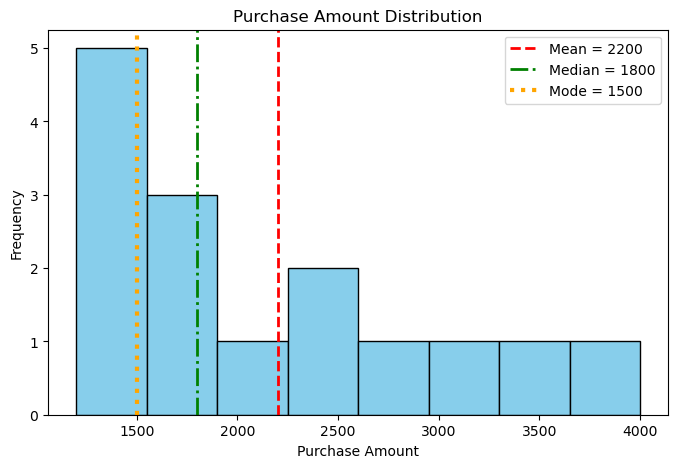

In [83]:

mean = pur["Purchase_Amount"].mean()
median = pur["Purchase_Amount"].median()
mode = pur["Purchase_Amount"].mode()[0]

plt.figure(figsize=(8,5))

plt.hist(
    pur["Purchase_Amount"],
    bins=8,
    edgecolor="black",
    color="skyblue"
)

plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.0f}")
plt.axvline(median, color="green", linestyle="-.", linewidth=2, label=f"Median = {median:.0f}")
plt.axvline(mode, color="orange", linestyle=":", linewidth=3, label=f"Mode = {mode}")

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

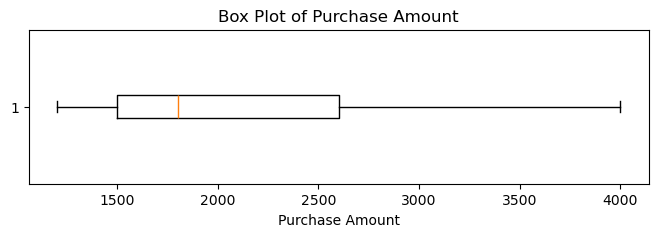

In [87]:
plt.figure(figsize=(8,2))

plt.boxplot(
    pur["Purchase_Amount"],
    vert=False
)

plt.title("Box Plot of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

### Range
    Range is the simplest measure of variability. It measures the difference between the largest and the smallest value in a dataset.

    It tells us how widely the data is spread.

    Formula
            Range= Maximum_Value − Minimum_Value

### Advantages
    Easy to calculate
    Easy to understand
    Gives a quick idea of data spread

### Limitations
    Uses only the minimum and maximum values
    Highly affected by outliers

In [30]:
range_value = pur["Purchase_Amount"].max() - pur["Purchase_Amount"].min()

print("Range :", range_value)


Range : 2800


### Mean Absolute Deviation(MAD)
    Mean Absolute Deviation (MAD) is the average of the absolute differences between each observation and the mean.

    It tells us how far, on average, the data values are from the mean.
    
    Formula:- 
$$
MAD = \frac{\sum |x_i - \bar{x}|}{n}
$$ 

In [31]:
mean = pur["Purchase_Amount"].mean()

MAD = np.sum(np.abs(pur["Purchase_Amount"] - mean))/len(pur['Purchase_Amount'])

print("MAD :", MAD)

MAD : 666.6666666666666


### Other Way Forming

In [88]:

mean = pur["Purchase_Amount"].mean()

MAD = (pur["Purchase_Amount"] - mean).abs().mean()

print(f"MAD : {MAD:.2f}")

MAD : 666.67


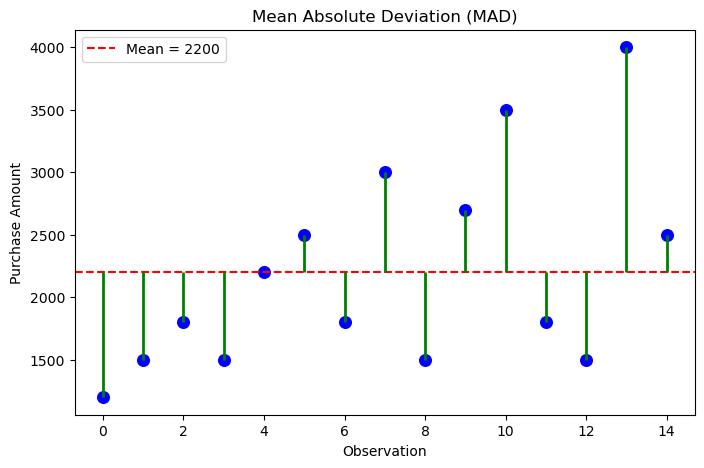

In [98]:
mean = pur["Purchase_Amount"].mean()

plt.figure(figsize=(8,5))

plt.scatter(pur.index,
            pur["Purchase_Amount"],
            color="blue",
            s=70)

plt.axhline(mean,
            color="red",
            linestyle="--",
            label=f"Mean = {mean:.0f}")

# Absolute deviation
for i, value in enumerate(pur["Purchase_Amount"]):
    plt.vlines(i,
               mean,
               value,
               color="green",
               linewidth=2)

plt.title("Mean Absolute Deviation (MAD)")
plt.xlabel("Observation")
plt.ylabel("Purchase Amount")
plt.legend()

plt.show()

### Variance
    Variance measures the average squared deviation of each data point from the mean.

    It shows how much the data is dispersed around the average.

    Formula 
    
$$
\sigma^2 = \frac{\sum (x_i-\mu)^2}{N}
$$

In [49]:
mean = pur["Purchase_Amount"].mean()

VAR = np.sum((pur["Purchase_Amount"] - mean) ** 2) / len(pur['Purchase_Amount'])

print(f"Population Variance : {VAR:.2f}")

Population Variance : 629333.33


In [50]:
mean=pur['Purchase_Amount'].mean()

VAR=np.sum((pur["Purchase_Amount"] - mean) **2)/(len(pur['Purchase_Amount'])-1)

print(f"Sample Variance :{VAR:.2f}")

Sample Variance :674285.71


### In-built Method  var()

In [64]:
# Sample Variance (Default ddof=1)
vari = pur["Purchase_Amount"].var(ddof=1)

print("Sample Variance :", vari)

Sample Variance : 674285.7142857143


In [95]:
# Population Variance
varia = pur["Purchase_Amount"].var(ddof=0)

print("Population Variance :",varia)

Population Variance : 629333.3333333334


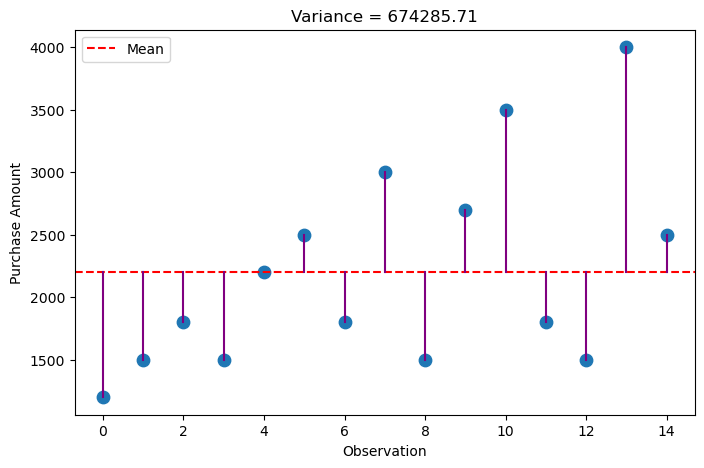

In [105]:
mean = pur["Purchase_Amount"].mean()

plt.figure(figsize=(8,5))

plt.scatter(
    pur.index,
    pur["Purchase_Amount"],
    s=80
)

plt.axhline(mean,
            color='red',
            linestyle='--',
            label='Mean')

for i, value in enumerate(pur["Purchase_Amount"]):
    plt.plot([i, i], [mean, value], color='purple')

plt.title((f"Variance = {var:.2f}"))
plt.xlabel("Observation")
plt.ylabel("Purchase Amount")
plt.legend()

plt.show()

### Standard Deviation
    Standard Deviation is the square root of the variance.

    It measures the average spread of the data around the mean using the original unit.

    Formula
$$
\sigma = \sqrt{\frac{\sum (x_i-\mu)^2}{N}}
$$

    OR
$$
SD = \sqrt{Variance}
$$

In [81]:
STD = np.sqrt(np.sum((pur["Purchase_Amount"] - mean) ** 2) / len(pur['Purchase_Amount']))

print("Population Standard Deviation:",STD)

Population Standard Deviation: 793.3053216343209


In [73]:
STD = np.sqrt(np.sum((pur["Purchase_Amount"] - mean) ** 2) / (len(pur['Purchase_Amount'])-1))

print("Sample Standard Deviation:",STD)

Standard Deviation: 821.1490207542809


### In-Built Method

In [75]:
std = purchase["Purchase_Amount"].std(ddof=0)

print("Population Standard Deviation :", std)

Population Standard Deviation : 793.3053216343209


In [82]:
std = purchase["Purchase_Amount"].std()

print(f"Sample Standard Deviation :{std:.2f}")

Sample Standard Deviation :821.15


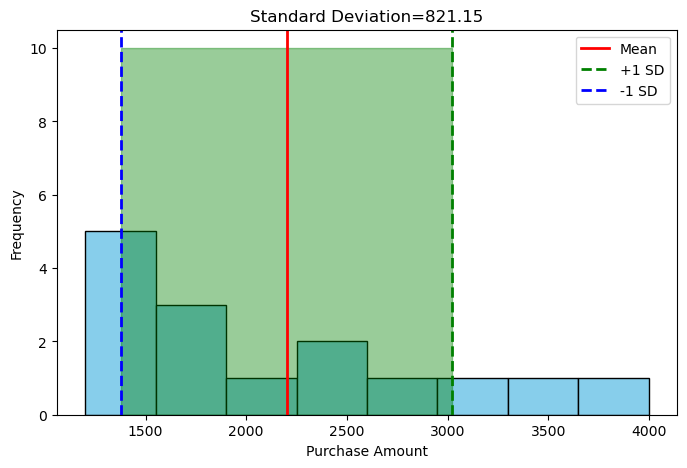

In [110]:
mean = pur["Purchase_Amount"].mean()
std = pur["Purchase_Amount"].std()

plt.figure(figsize=(8,5))

plt.hist(
    pur["Purchase_Amount"],
    bins=8,
    color="skyblue",
    edgecolor="black"
)

plt.axvline(mean,
            color="red",
            linewidth=2,
            label="Mean")

plt.axvline(mean+std,
            color="green",
            linestyle="--",
            linewidth=2,
            label="+1 SD")

plt.axvline(mean-std,
            color="blue",
            linestyle="--",
            linewidth=2,
            label="-1 SD")

plt.fill_betweenx(
    [0,10],
    mean-std,
    mean+std,
    color="green",
    alpha=0.4
)

plt.title(f"Standard Deviation={std:.2f}")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()